# CSC3831 Coursework Part 1: Data Engineering



## Table Of Contents:
### 0. Imports and Loading Data [0]
### 1. Data Understanding [7]
-  #### 1.1 Dataset overview  
-  #### 1.2 Summary statistics  
-  #### 1.3 Missing values  
-  #### 1.4 Outliers records   
-  #### 1.5 EDA summary  
### 2. Outlier Identification [10]
-  #### 2.1 Statistical outlier detection
-  #### 2.2 Algorithmic outlier detection
-  #### 2.3 Comparison of statistical vs algorithmic results
-  #### 2.4 Benefits and Detriments
### 3. Imputation [10]
-  #### 3.1 Identify features to impute or remove
-  #### 3.2 KNN Imputation
-  #### 3.3 MICE Imputation
-  #### 3.4 Compare feature distributions (original vs knn vs mice)
-  #### 3.5 Regressor comparison on three datasets

# 0. Imports and Loading Data

In [684]:
# Loading in standard packages for analysis, feel free to add an extra packages you'd like to use here
import random
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

# Loading in the corrupted dataset to be used in analysis and imputation
hc_path = 'https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv'
houses_corrupted = pd.read_csv(hc_path, header=0)
# Remove an artifact from the dataset
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)

Above we've loaded in a corrupted version of a housing dataset. The anomalies need to be dealt with and missing values imputed.

# 1. Data Understanding [7]
### Tasks:
- Perform ad hoc EDA to understand and describe what you see in the raw dataset
  - Include graphs, statistics, and written descriptions as appropriate
  - Any extra information about the data you can provide here is useful, think about performing an analysis (ED**A**), what would you find interesting or useful?
- Identify features with missing records, outlier records


## 1.1 Dataset overview

In [685]:
houses_corrupted.head(10)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,NaN,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,NaN,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
5,269700.0,4.0368,52.0,919.0,213.0,413.0,193.0,37.85,-122.25
6,299200.0,3.6591,52.0,2535.0,489.0,1094.0,514.0,37.84,-122.25
7,241400.0,3.1200,52.0,3104.0,687.0,1157.0,647.0,37.84,-122.25
8,226700.0,2.0804,42.0,2555.0,665.0,1206.0,595.0,37.84,-122.26
9,261100.0,3.6912,52.0,3549.0,707.0,1551.0,714.0,37.84,-122.25


In [686]:
houses_corrupted.shape

(20640, 9)

In [687]:
houses_corrupted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_house_value  20640 non-null  float64
 1   median_income       18576 non-null  float64
 2   housing_median_age  18576 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          18576 non-null  float64
 6   households          20640 non-null  float64
 7   latitude            20640 non-null  float64
 8   longitude           20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Based on the column names, the dataset appears to describe both housing and economic characteristics for different geographic locations. After inputting the first 10 locations into google maps, it appears all of them track to neighborhoods in California, USA. Therefore, each row likely corresponds to small neighborhoods, but i'm uncertain whether this whole dataset contributes to just California, or a wider region. Fortunately, the key point to focus on is that each record describes different housing locations, linking to their economic attributes.

Looking at 'houses_corrupted.shape' there are 20,640 rows in total and 9 columns all together, where each row corresponds to a geographic location.

Looking at 'houses_corrupted.info()', 3 rows contain missing values which are median_income, housing_median_age, and population. Missing values will be analysed properly later on through the coursework.

Now let's move on to the columns of the dataset. The median_house_value is very likely to be the target variable, assuming it means the average house prince in that area. median_income is the average income per location. housing_median_age is the average housing age per location. total_rooms and total_bedrooms are the number of rooms/bedrooms in total per location. The population column is the total number of people per location. Finally, the households column is the total number of houses per location.


## 1.2 Summary statistics 

In [688]:
houses_corrupted.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,20640.000000,18576.000000,18576.000000,20640.000000,20640.000000,18576.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.929958,28.324182,2635.763081,537.898014,1488.069283,499.539680,35.631861,-119.569704
std,115395.615874,1.964296,12.584914,2181.615252,421.247906,1170.585810,382.329753,2.135952,2.003532
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000
25%,119600.000000,2.560300,18.000000,1447.750000,295.000000,839.000000,280.000000,33.930000,-121.800000
50%,179700.000000,3.572400,28.000000,2127.000000,435.000000,1227.000000,409.000000,34.260000,-118.490000
75%,264725.000000,4.870050,37.000000,3148.000000,647.000000,1803.000000,605.000000,37.710000,-118.010000
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000


In [689]:
houses_corrupted.skew()

median_house_value    0.977763
median_income         1.587611
housing_median_age    0.085426
total_rooms           4.147343
total_bedrooms        3.453073
population            4.825861
households            3.410438
latitude              0.465953
longitude            -0.297801
dtype: float64

### Analysis per column from written statistics displayed:

median_house_value:
-  House prices between 14.999k and just over 500k, suggesting wide spread of house prices.
-  Right skewed as shown positive.

median_income:
-  Most neighborhoods contain people with lower income as the median is much more closer to min than max.
-  Right skewed as shown positive.

housing_median_age:
-  The ages are between 1 and 52. However, looking at the interquartile range of 18 and 37, it suggests most locations consist of housings that are neither old or new. 
-  Right skewed but extremely close to 0. Therefore, almost symmetrical around the median.

total_rooms:
-  Number of rooms per neighborhood are between 2 and 39,320. Therefore, this dataset likely includes both extremely small and large neighborhoods.
- Strongly right skewed which means a small number of neighborhoods have extremely many rooms.

total_bedrooms:
-  Data shows very similar to total_rooms which suggests a high correlation

population:
-  Also very similar to total_rooms as it ranges from 3 to 35,682 per area, suggesting the dataset contains neighborhoods being either extremely low and highly populated.
-  Strongly right skewed

households:
-  Number of houses per neighborhood range between 1 and 6,082.
-  Strongly right skewed.

After analysing just from the describe and skew tables, I can strongly say that total_rooms, total_bedrooms, population, and households all have a strong correlation between each other. This means one column has a big affect on the other three. Also, only these four columns have very strong skews.
However, it would be best to visually prove this analysis by using a heatmap:

<Axes: >

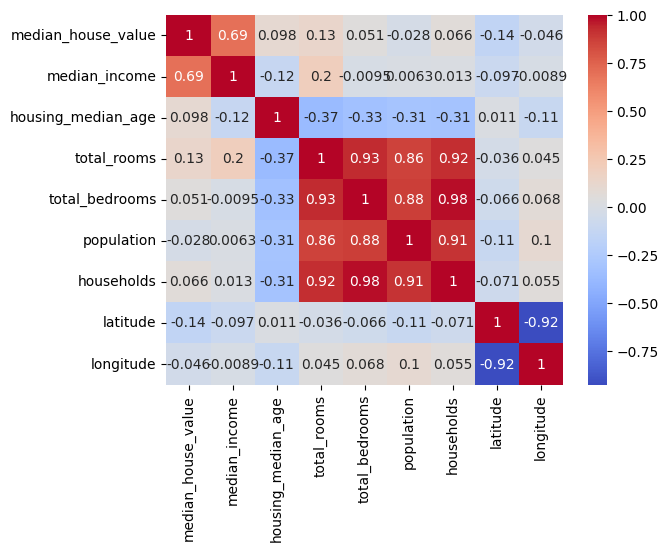

In [690]:
sns.heatmap(houses_corrupted.corr(), annot=True, cmap='coolwarm')

You can see that big red box near the centre consists of these four columns. However, I was unable to analyse that median_income and median_house_value have a strong correlation. This suggests that most neighborhoods consists of people that have higher incomes, are very likely to have higher priced houses.

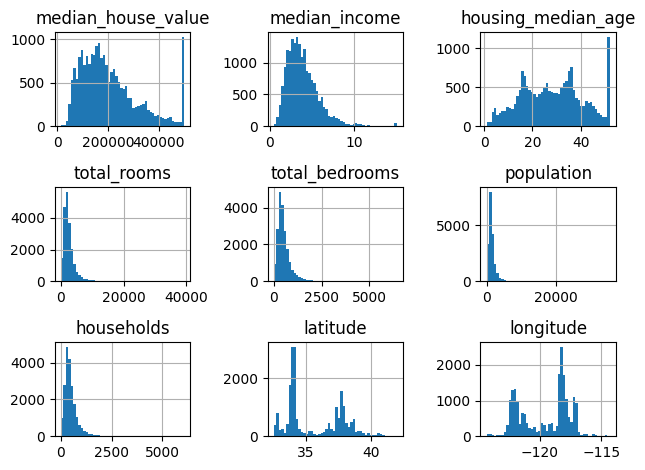

In [691]:
houses_corrupted[['median_house_value', 'median_income', 'housing_median_age', 
    'total_rooms', 'total_bedrooms', 'population', 'households', 'latitude', 'longitude']].hist(
        bins=50)
plt.tight_layout()

In these histograms, total_rooms, total_bedrooms, population, and households are extremely right skewed, which shows most areas have the average number of these characteristics. 

median_house_value has a long right tail which shows some neighborhoods have much higher house prices than the rest. The same with housing_median_age where majority of neighborhoods have younger or middle-aged housing, but an extremely small minority of neighborhoods contain very old houses.

Looking at median_income, it has a right skewed distribution, suggesting most neighborhoods are in a relatively narrow income band whilst there are a small number of high‑income areas.

## 1.3 Missing values 

This section only focuses on identifying the missing values. They will be handled later on through this coursework.

In [692]:
houses_corrupted.isnull().sum()

median_house_value       0
median_income         2064
housing_median_age    2064
total_rooms              0
total_bedrooms           0
population            2064
households               0
latitude                 0
longitude                0
dtype: int64

Looking at the series above, it seems that only three of the columns contain missing values. What's interesting is that these columns have exactly 2064 missing entries which suggests that when a value is missing, all three variables tend to be missing together in the same row. Let's see if this is the case.

In [693]:
columns = ['median_income', 'housing_median_age', 'population']

any_missing_rows = houses_corrupted[houses_corrupted.isnull().any(axis=1)]
print(any_missing_rows[columns].head(10))
print(any_missing_rows.shape)

    median_income  housing_median_age  population
2          7.2574                52.0         NaN
3          5.6431                52.0         NaN
10         3.2031                 NaN       910.0
14            NaN                52.0      1212.0
16            NaN                52.0       793.0
17            NaN                52.0         NaN
18            NaN                 NaN       990.0
19            NaN                52.0       690.0
20            NaN                40.0       409.0
21            NaN                 NaN       929.0
(5581, 9)


As you can see, these first 10 rows contain one or two null values, and the total number of rows containing at least one is 5581 (more than 2064). Furthermore, not one row is shown to have 3 consecutive null values. However, this does not mean the same is applied to the rest of the dataset. 

In [694]:
three_missing_rows = houses_corrupted[houses_corrupted[columns].isnull().all(axis=1)]
print(three_missing_rows[columns])
print(f'Shape: {three_missing_rows.shape}')

       median_income  housing_median_age  population
802              NaN                 NaN         NaN
813              NaN                 NaN         NaN
1278             NaN                 NaN         NaN
4158             NaN                 NaN         NaN
4635             NaN                 NaN         NaN
4752             NaN                 NaN         NaN
6121             NaN                 NaN         NaN
6127             NaN                 NaN         NaN
6263             NaN                 NaN         NaN
6267             NaN                 NaN         NaN
6273             NaN                 NaN         NaN
6280             NaN                 NaN         NaN
6940             NaN                 NaN         NaN
6951             NaN                 NaN         NaN
7021             NaN                 NaN         NaN
7030             NaN                 NaN         NaN
7455             NaN                 NaN         NaN
7661             NaN                 NaN      

Throughout the whole dataset, there are 37 rows in total that have 3 null values in the columns: median_income, housing_median_age, and population. 

As I mentioned before, I will handle these missing values later on through the coursework. Some rows will be handled differently depending on the number of missing values per row.

## 1.4 Outliers records 

In [695]:
num_cols = ['median_house_value', 'median_income', 'housing_median_age',
            'total_rooms', 'total_bedrooms', 'population', 'households']

Q1 = houses_corrupted[num_cols].quantile(0.25)
Q3 = houses_corrupted[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (houses_corrupted[num_cols] < lower_bound) | (houses_corrupted[num_cols] > upper_bound)
print(outliers.sum())

median_house_value    1071
median_income          562
housing_median_age       0
total_rooms           1287
total_bedrooms        1282
population            1077
households            1220
dtype: int64


Above shows the total number of outliers there are per column in the whole dataset. This is done by the IQR method. I decided to not include longitude and latitude as each value will be different, especially when it involves geographical locations.

There are over 1000 outliers for columns: median_house_value, total_rooms, total_bedrooms, population, and households. Since these are related to housing and neighborhood sizing, it suggests these outliers come from neighborhoods that are extremely large, and are being compared to average sized areas.

With median_income and housing_median_age having a number of outliers between a few and none, suggests that income levels and housing ages vary a lot less that the rest of the housing attributes.

## 1.5 EDA Summary

Overall, the dataset appears to describe housing and economic characteristics of different neighborhoods, with median_house_value as the likely target and other variables capturing income, housing characteristics, population, and location. The distributions show that price and size‑related variables are strongly right‑skewed with some very large values, while income and housing age are less extreme. Missing‑value analysis indicates that only median_income, housing_median_age, and population contain gaps, and these tend to be missing together in about 10% of rows. The IQR method confirms that outliers are concentrated in the price and size variables, suggesting a small number of unusually large or expensive neighborhoods that will need handled later.

# 2. Outlier Identification [10]
### Tasks:
- Utilise a statistical outlier detection approach (i.e., **no** KNN, LOF, 1Class SVM)
- Utilise an algorithmic outlier detection method of your choice
- Compare results and decide what to do with identified outleirs
  - Include graphs, statistics, and written descriptions as appropriate
- Explain what you are doing, and why your analysis is appropriate
- Comment on benefits/detriments of statistical and algorithmic outlier detection approaches

## 2.1 Statistical Outlier Detection

# 3. Imputation [10]
### Tasks:
- Identify which features should be imputed and which should be removed
  - Provide a written rationale for this decision
- Impute the missing records using KNN imputation
- Impute the missing records using MICE imputation
- Compare both imputed datasets feature distributions against each other and the non-imputed data
- Build a regressor on all three datasets
  - Use regression models to predict house median price
  - Compare regressors of non-imputed data against imputed datas
  - **Note**: If you're struggling to compare against the original dataset focus on comparing the two imputed datasets against each other

In [696]:
# Use this dataset for comparison against the imputed datasets
h_path = 'https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/ORIGINAL/houses.csv'

## 3.1 Identify features to impute or remove

Since I have already identified that there are null values contained inside this dataset, I need to make a decision on how to handle them. There are null values contained only in 3 columns: median_income, housing_median_age, and population. Out of 20,640 rows in the dataset, 5,581 of them contain at least one null value. I need make a decision on how to handle these rows. There are 2 options, imputation and deletion. 

I have identified that 37 of those rows contain 3 consecutive null values. This mean there is no need to impute these rows as nearly half the data in each one is non-existent. Therefore, I have come with the decision to delete those 37 rows first. Afterwards, I will impute the remaining rows containing one or two null values.

In [697]:
three_missing_rows = houses_corrupted[houses_corrupted[columns].isnull().all(axis=1)]
print(three_missing_rows[columns])
print(f'Shape: {three_missing_rows.shape}')

       median_income  housing_median_age  population
802              NaN                 NaN         NaN
813              NaN                 NaN         NaN
1278             NaN                 NaN         NaN
4158             NaN                 NaN         NaN
4635             NaN                 NaN         NaN
4752             NaN                 NaN         NaN
6121             NaN                 NaN         NaN
6127             NaN                 NaN         NaN
6263             NaN                 NaN         NaN
6267             NaN                 NaN         NaN
6273             NaN                 NaN         NaN
6280             NaN                 NaN         NaN
6940             NaN                 NaN         NaN
6951             NaN                 NaN         NaN
7021             NaN                 NaN         NaN
7030             NaN                 NaN         NaN
7455             NaN                 NaN         NaN
7661             NaN                 NaN      

Above displays all the rows containing three consecutive null values in these columns. The shape is also displayed at the bottom.

In [698]:
houses_corrupted.drop(index=three_missing_rows.index, inplace=True)

In [699]:
print(three_missing_rows[columns])
print(f'Shape: {three_missing_rows.shape}')

       median_income  housing_median_age  population
802              NaN                 NaN         NaN
813              NaN                 NaN         NaN
1278             NaN                 NaN         NaN
4158             NaN                 NaN         NaN
4635             NaN                 NaN         NaN
4752             NaN                 NaN         NaN
6121             NaN                 NaN         NaN
6127             NaN                 NaN         NaN
6263             NaN                 NaN         NaN
6267             NaN                 NaN         NaN
6273             NaN                 NaN         NaN
6280             NaN                 NaN         NaN
6940             NaN                 NaN         NaN
6951             NaN                 NaN         NaN
7021             NaN                 NaN         NaN
7030             NaN                 NaN         NaN
7455             NaN                 NaN         NaN
7661             NaN                 NaN      

In [667]:
columns = ['median_income', 'housing_median_age', 'population']

any_missing_rows = houses_corrupted[houses_corrupted.isnull().any(axis=1)]
print(any_missing_rows[columns].head(10))
print(any_missing_rows.shape)

    median_income  housing_median_age  population
2          7.2574                52.0         NaN
3          5.6431                52.0         NaN
10         3.2031                 NaN       910.0
14            NaN                52.0      1212.0
16            NaN                52.0       793.0
17            NaN                52.0         NaN
18            NaN                 NaN       990.0
19            NaN                52.0       690.0
20            NaN                40.0       409.0
21            NaN                 NaN       929.0
(5581, 9)


In [669]:
houses_corrupted.drop(index=three_missing_rows.index, inplace=True)


In [670]:
len(houses_corrupted)

20603

In [671]:
houses_corrupted.iloc[800:804]

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
800,157600.0,NaN,27.0,2784.0,723.0,2028.0,693.0,37.63,-122.07
801,190900.0,4.7083,25.0,4524.0,860.0,2426.0,862.0,37.64,-122.07
803,350000.0,3.5541,20.0,1655.0,450.0,857.0,430.0,37.64,-122.06
804,158200.0,NaN,33.0,1227.0,286.0,NaN,291.0,37.65,-122.06


In [672]:
houses_corrupted.reset_index(drop=True, inplace=True)

In [673]:
houses_corrupted.iloc[800:804]

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
800,157600.0,NaN,27.0,2784.0,723.0,2028.0,693.0,37.63,-122.07
801,190900.0,4.7083,25.0,4524.0,860.0,2426.0,862.0,37.64,-122.07
802,350000.0,3.5541,20.0,1655.0,450.0,857.0,430.0,37.64,-122.06
803,158200.0,NaN,33.0,1227.0,286.0,NaN,291.0,37.65,-122.06


In [674]:
from sklearn.impute import KNNImputer

knn_df = houses_corrupted.copy()

selected_columns = ['median_income', 'housing_median_age', 'population']

imputer = KNNImputer(n_neighbors=5)

knn_df[selected_columns] = imputer.fit_transform(knn_df[selected_columns])

In [675]:
knn_df.head(20)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.32520,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.30140,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.25740,52.0,1467.0,190.0,994.0,177.0,37.85,-122.24
3,341300.0,5.64310,52.0,1274.0,235.0,958.0,219.0,37.85,-122.25
4,342200.0,3.84620,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
5,269700.0,4.03680,52.0,919.0,213.0,413.0,193.0,37.85,-122.25
6,299200.0,3.65910,52.0,2535.0,489.0,1094.0,514.0,37.84,-122.25
7,241400.0,3.12000,52.0,3104.0,687.0,1157.0,647.0,37.84,-122.25
8,226700.0,2.08040,42.0,2555.0,665.0,1206.0,595.0,37.84,-122.26
9,261100.0,3.69120,52.0,3549.0,707.0,1551.0,714.0,37.84,-122.25


In [676]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_df = houses_corrupted.copy()

imputer = IterativeImputer(max_iter=10, random_state=0)

mice_df[selected_columns] = imputer.fit_transform(houses_corrupted[selected_columns])

In [677]:
mice_df.head(20)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.325200,41.000000,880.0,129.0,322.000000,126.0,37.88,-122.23
1,358500.0,8.301400,21.000000,7099.0,1106.0,2401.000000,1138.0,37.86,-122.22
2,352100.0,7.257400,52.000000,1467.0,190.0,676.377297,177.0,37.85,-122.24
3,341300.0,5.643100,52.000000,1274.0,235.0,713.920992,219.0,37.85,-122.25
4,342200.0,3.846200,52.000000,1627.0,280.0,565.000000,259.0,37.85,-122.25
5,269700.0,4.036800,52.000000,919.0,213.0,413.000000,193.0,37.85,-122.25
6,299200.0,3.659100,52.000000,2535.0,489.0,1094.000000,514.0,37.84,-122.25
7,241400.0,3.120000,52.000000,3104.0,687.0,1157.000000,647.0,37.84,-122.25
8,226700.0,2.080400,42.000000,2555.0,665.0,1206.000000,595.0,37.84,-122.26
9,261100.0,3.691200,52.000000,3549.0,707.0,1551.000000,714.0,37.84,-122.25


In [678]:
knn_df.isnull().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

In [679]:
mice_df.isnull().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

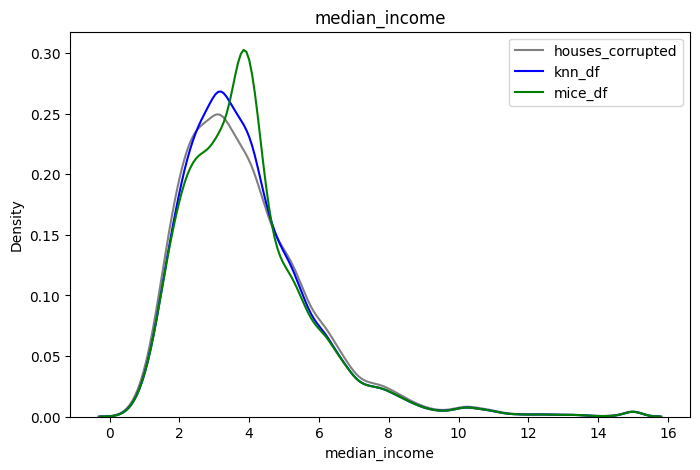

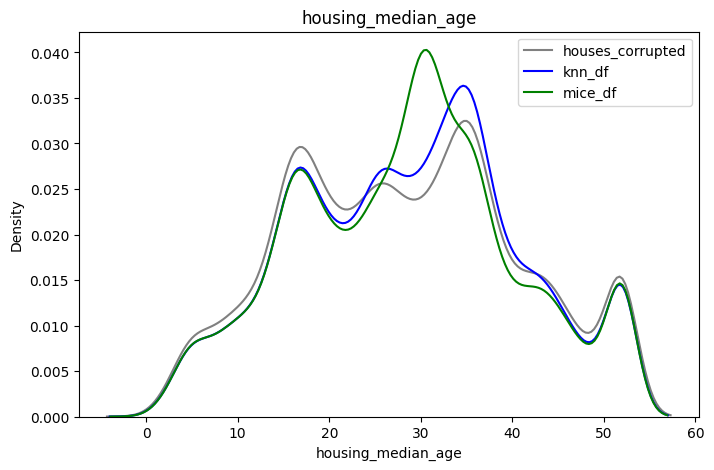

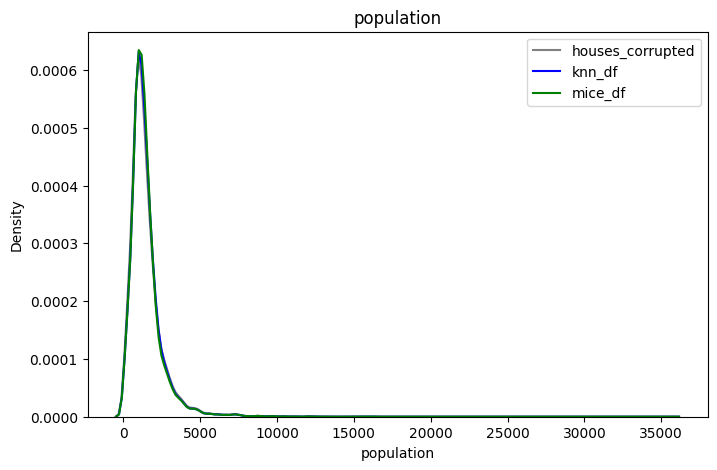

In [680]:
for col in selected_columns:
    plt.figure(figsize=(8,5))
    sns.kdeplot(houses_corrupted[col], label='houses_corrupted', color='gray')
    sns.kdeplot(knn_df[col], label='knn_df', color='blue')
    sns.kdeplot(mice_df[col], label='mice_df', color='green')
    plt.title(col)
    plt.legend()
    plt.show()

In [681]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

datasets = {
    "houses_corrupted": houses_corrupted.dropna(),
    "knn_df": knn_df,
    "mice_df": mice_df
}

for name, data in datasets.items():
    X = data.drop('median_house_value', axis=1)
    y = data['median_house_value']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    print(f"{name}: R² = {score:.4f}")

houses_corrupted: R² = 0.6548
knn_df: R² = 0.6145
mice_df: R² = 0.6153


In [682]:
for col in houses_corrupted.columns:
    Q1 = houses_corrupted[col].quantile(0.25)
    Q3 = houses_corrupted[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = houses_corrupted[(houses_corrupted[col] < lower) | (houses_corrupted[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

median_house_value: 1062 outliers
median_income: 562 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1284 outliers
population: 1077 outliers
households: 1220 outliers
latitude: 0 outliers
longitude: 0 outliers


In [683]:
from sklearn.ensemble import IsolationForest

X = houses_corrupted.select_dtypes(include=[np.number])

isf = IsolationForest(contamination=0.1, random_state=42)
outlier_predictions = isf.fit_predict(X)

houses_corrupted['isolation_forest_outlier'] = outlier_predictions
outliers_iso = houses_corrupted[houses_corrupted['isolation_forest_outlier'] == -1]
normal_iso = houses_corrupted[houses_corrupted['isolation_forest_outlier'] == 1]

print(f"Isolation Forest Results:")
print(f"Total outliers detected: {len(outliers_iso)}")
print(f"Normal records: {len(normal_iso)}")

Isolation Forest Results:
Total outliers detected: 2061
Normal records: 18542


### 4. Conclusions & Throughts [3]
- Discuss methods used for anomaly detection, pros/cons of each method
- Discuss challenges/difficulties in anomaly detection implementation
- Discuss methods used for imputation, pros/cons of each method
- Discuss challenges/difficulties in imputation implementation